<a href="https://colab.research.google.com/github/amitshara/Google-Playstore-Project/blob/main/05.Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
import warnings

warnings.filterwarnings("ignore")


In [2]:
#Load Dataset
df = pd.read_csv("Play Store Data.csv")

In [3]:
#SHOW CHART ONLY BETWEEN 5 PM AND 7 PM IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

if not (17 <= current_time.hour < 19):
    print("Dashboard Hidden: Chart should only be visible between 5 PM and 7 PM IST")
    exit()

In [4]:
#Data Cleaning
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [5]:
# Size Cleaning
# Converts:
# 19M -> 19
# 8.7M -> 8.7
# Removes "Varies with device"
df = df[df["Size"].notna()]

df = df[df["Size"].str.contains("M", na=False)]

df["Size_MB"] = (
    df["Size"]
    .str.replace("M", "", regex=False)
    .astype(float)
)

In [6]:
# Installs Cleaning
# Example:
# 10,000+ -> 10000
df["Installs_Num"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs_Num"] = pd.to_numeric(
    df["Installs_Num"],
    errors="coerce"
)


In [7]:
# CATEGORY FILTER
allowed_categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENTS"
]

In [8]:
# Sentiment_Subjectivity column does NOT exist
# in Play Store Apps dataset.
#
# If available:
# (df["Sentiment_Subjectivity"] > 0.5)
filtered_df = df[
    (df["Rating"] > 3.5) &
    (df["Category"].isin(allowed_categories)) &
    (df["Reviews"] > 500) &
    (df["Installs_Num"] > 50000) &
    (~df["App"].str.contains("S", case=False, na=False))
].copy()

In [9]:
#TRANSLATE CATEGORIES
translation_map = {
    "BEAUTY": "सौंदर्य",        # Hindi
    "BUSINESS": "வணிகம்",      # Tamil
    "DATING": "Partnersuche"   # German
}

filtered_df["Category_Display"] = (
    filtered_df["Category"]
    .replace(translation_map)
)

In [15]:
# COLOR MAPPING
# GAME CATEGORY MUST BE PINK
def get_color(category):
    if category == "GAME":
        return "pink"
    return "skyblue"

colors = filtered_df["Category"].apply(get_color)


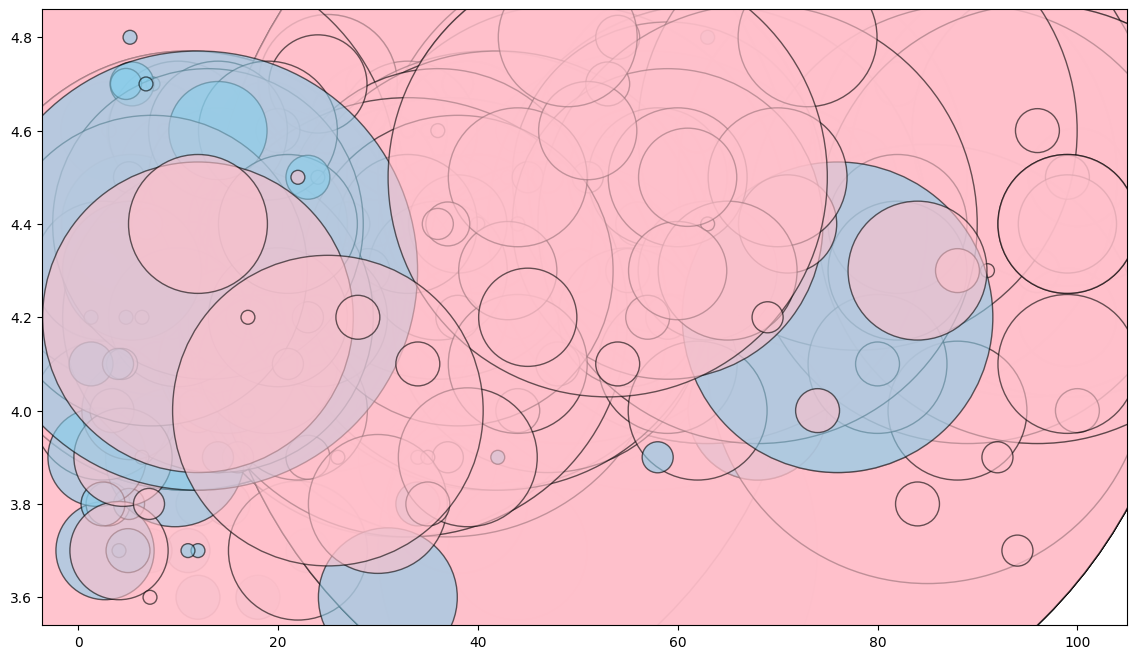

In [11]:
# BUBBLE CHART
plt.figure(figsize=(14,8))

scatter = plt.scatter(
    filtered_df["Size_MB"],
    filtered_df["Rating"],
    s=filtered_df["Installs_Num"] / 1000,
    c=colors,
    alpha=0.6,
    edgecolors="black"
)

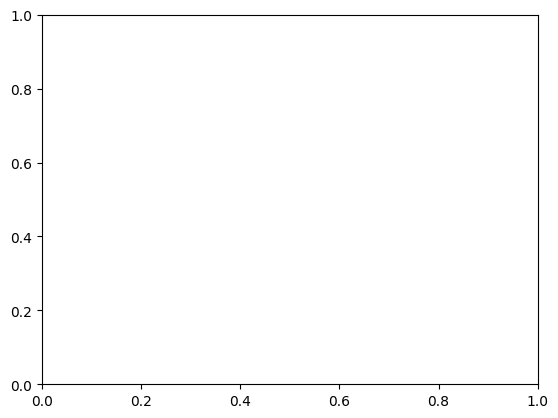

In [12]:
#ANNOTATE POINTS WITH TRANSLATED CATEGORY
for _, row in filtered_df.iterrows():
    plt.annotate(
        row["Category_Display"],
        (row["Size_MB"], row["Rating"]),
        fontsize=8,
        alpha=0.8
    )


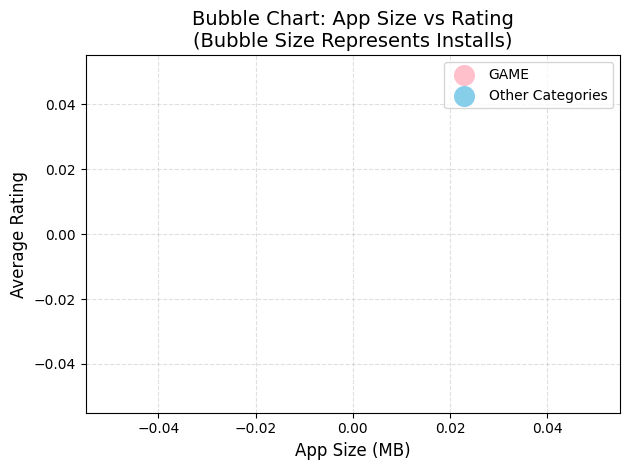

In [13]:
##CHART FORMATTING
plt.title(
    "Bubble Chart: App Size vs Rating\n"
    "(Bubble Size Represents Installs)",
    fontsize=14
)

plt.xlabel("App Size (MB)", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

# Custom Legend
plt.scatter([], [], s=200, color="pink", label="GAME")
plt.scatter([], [], s=200, color="skyblue", label="Other Categories")

plt.legend()

plt.tight_layout()

plt.show()

In [14]:
print("\nFiltered Records:", len(filtered_df))

print("\nCategories Included:")
print(filtered_df["Category_Display"].unique())


Filtered Records: 406

Categories Included:
['सौंदर्य' 'வணிகம்' 'COMICS' 'COMMUNICATION' 'Partnersuche'
 'ENTERTAINMENT' 'EVENTS' 'GAME' 'SOCIAL']
